In [1]:
import masking_effects_on_xai_techniques.utils as utils
import masking_effects_on_xai_techniques.plot_creator as plot_creator
import masking_effects_on_xai_techniques.plot_creator_2 as plot_creator_2
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Utility vs Generalization

In [2]:
pd.read_csv("../data/adult/clean.csv")["income"].value_counts(normalize=True)

income
<=50K    0.757649
>50K     0.242351
Name: proportion, dtype: float64

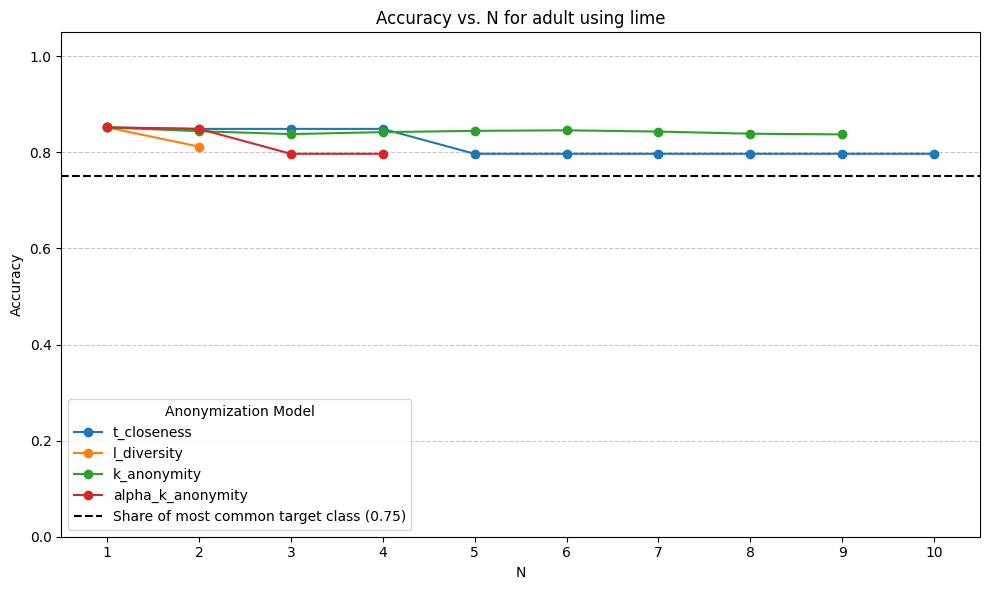

In [3]:
adult = plot_creator.Comparer("adult", "..")
adult.plot_accuracy("lime", 0.75)

The classes in this dataset has a 1:3 relation, i.e. 75% is part of the low income target class. This model does little better than just guessing.  
The accuracy of k anonymity is rather constant. Since the dataset is large and we humans share a lot of basic properties such as education and marriage relationship, we look quite similar. Also, it is a big dataset, so equivalence classes of size 256 is not that much. This coupled with the fact that the accuracy does not fall that much, indicates that the dataset is not generalized that much.  
We see again that an early t closeness dataset satisfy a lot of different values of t

In [4]:
pd.read_csv("../data/usa_house/clean.csv")["Price"].value_counts(normalize=True)

Price
2    0.316818
3    0.315609
1    0.151057
4    0.149446
0    0.034240
5    0.032830
Name: proportion, dtype: float64

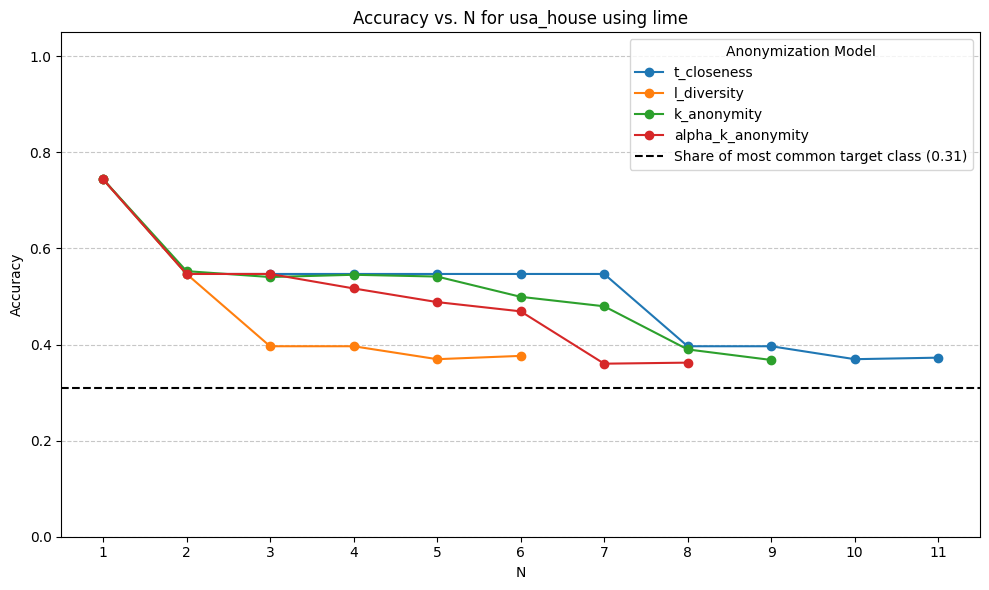

In [5]:
usa_house = plot_creator.Comparer("usa_house", "..")
usa_house.plot_accuracy("lime", 0.31)

The change in accuracy graduarly fall for alpha-k-anonymity indicating that higher constraints are slowly met my generalizing a feature one at a time.  Why? A lot of equivalence classes contain elements from different target classes. Once alpha becomes low enough, there must be a higher number of different target classes in an equivalence class which only occurs when granularity is lost
The quick drop in accuracy for l_diversity indicates that it must quickly generalize much of the dataset to fulfill the requirement. Probably because of the way the target classes have been constructed. Outliers have been removed since we are talking about houses which most of the time are quite similar, instances that is part of the same target class can be expected to look rather similar. An l-diversity of 2 can rather easily be obtained, because all classes border at least one other class, meaning they probably easily have some instances that share a lot of feature values. Once l become larger than two, for the two outer most target classes they must be part of an equivalence class where instances of a non-neighbouring target class also are. This happens rarely. The data must therefore loose a lot of granularity before it happens  
Remember, k_anonimity increase exponential. Initiallly it does not need to generalize the dataset further because k does not change a lot and the dataset is so big. Once k gets big enough we loose a lot of granularity  
I am not sure why t-closeness is so flat for so long

In [6]:
pd.read_csv("../data/cervic_cancer/clean.csv")["disease"].value_counts(normalize=True)

disease
0    0.142857
5    0.142857
4    0.142857
2    0.142857
3    0.142857
6    0.142857
1    0.142857
Name: proportion, dtype: float64

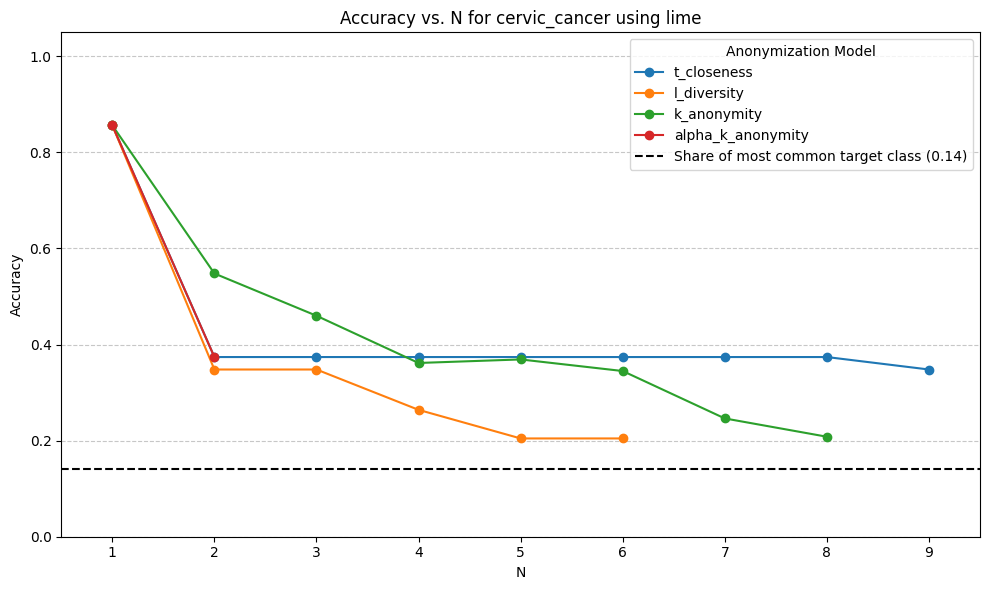

In [7]:
cervic_cancer = plot_creator.Comparer(
    "cervic_cancer",
    "..",
)
cervic_cancer.plot_accuracy("lime", 0.14)

This dataset has a lot of features. Most of these features are binary except a few numeric features. These numeric features are instanly genralized to a very high generalization, because the high number of binary features makes it quite probably that just one is different and the Mondrian algorthm always genrealizes the feature with the most diversity. Once all the features have been generalized to a level where they are all binary, they are all anonymized in the order in which they appear in the dataframe column.  
Here we see for both t_closeness and k_anonymity that the accuracy actually increase as the datasets are generalized even more. Why is this? Again, the curse of dimensionality. As more and more features are suppressed, the dimensionality is slowly reduced. The accuracy is alrady very low, so this lower dimensional function might just perform a little better.  
Apart from that, it can be pointless making conclusions from this graph, since the accuracy is so low

# Importance

## Lime

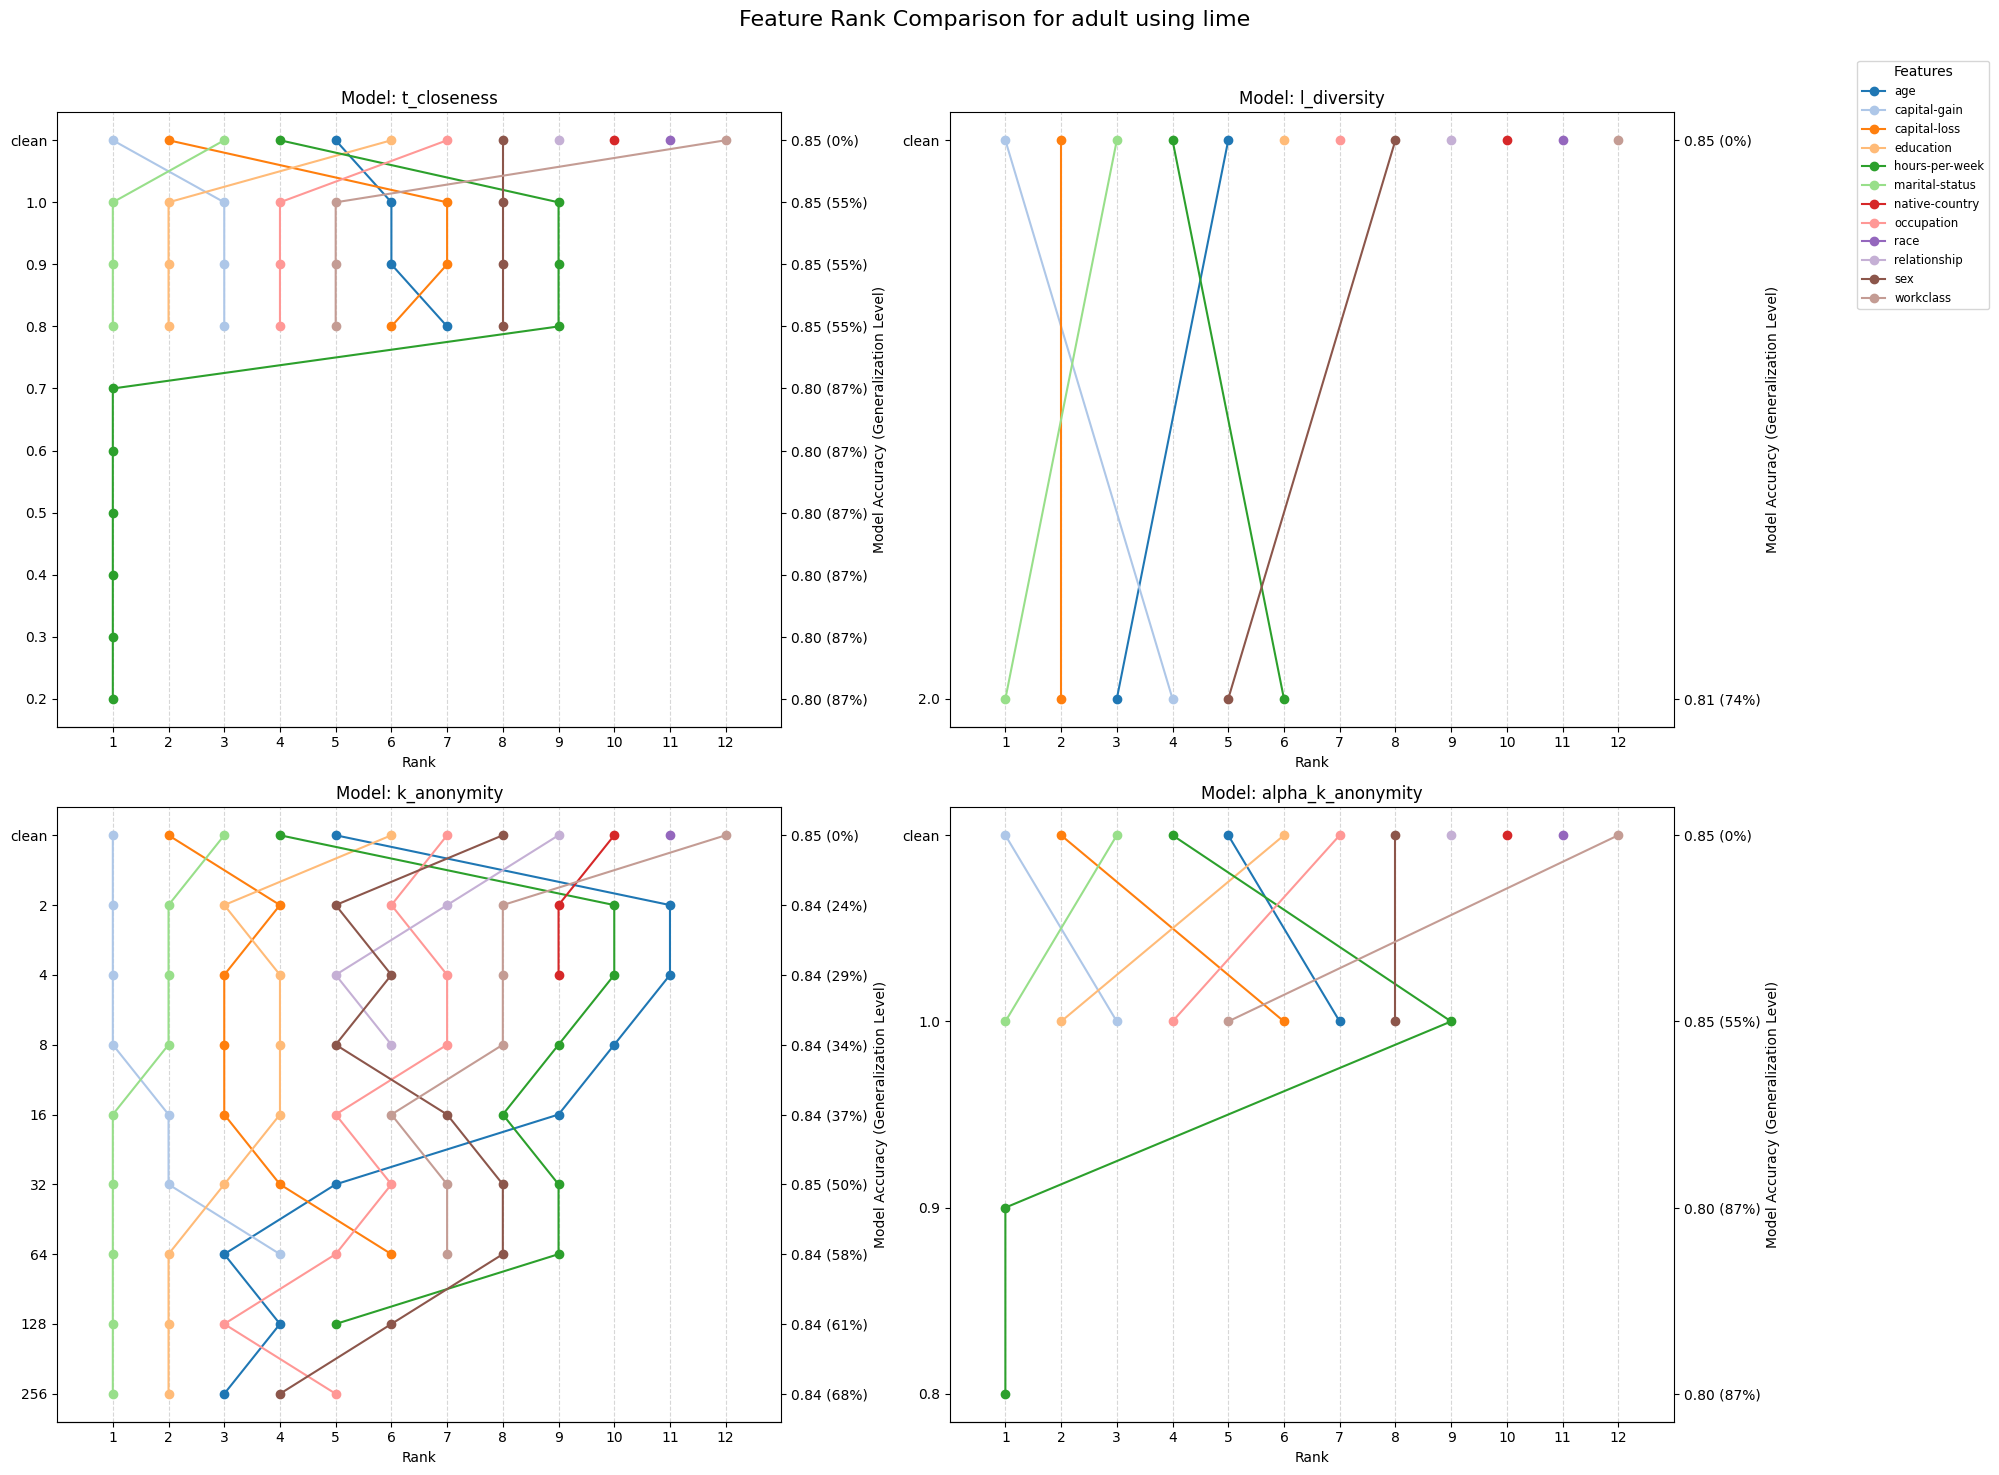

In [8]:
adult.plot_line("lime")

Note how the significance is rather high. ALso note that about 75% of all instances are part of the majority class. It does well just by guessing the majority target class. Apart from that, it is pretty much the same story as before. The fact that 2-diversity and $\alpha<1$ generalizes the data so much, indicates it is difficult to achieve it for the dataset. Maye if k was incread? Juding from the k anonymity plot, a higher k can easily be picked. If  a k of 64 is used, we still have the same amount of features as $k=10$ and a similar accuracy.

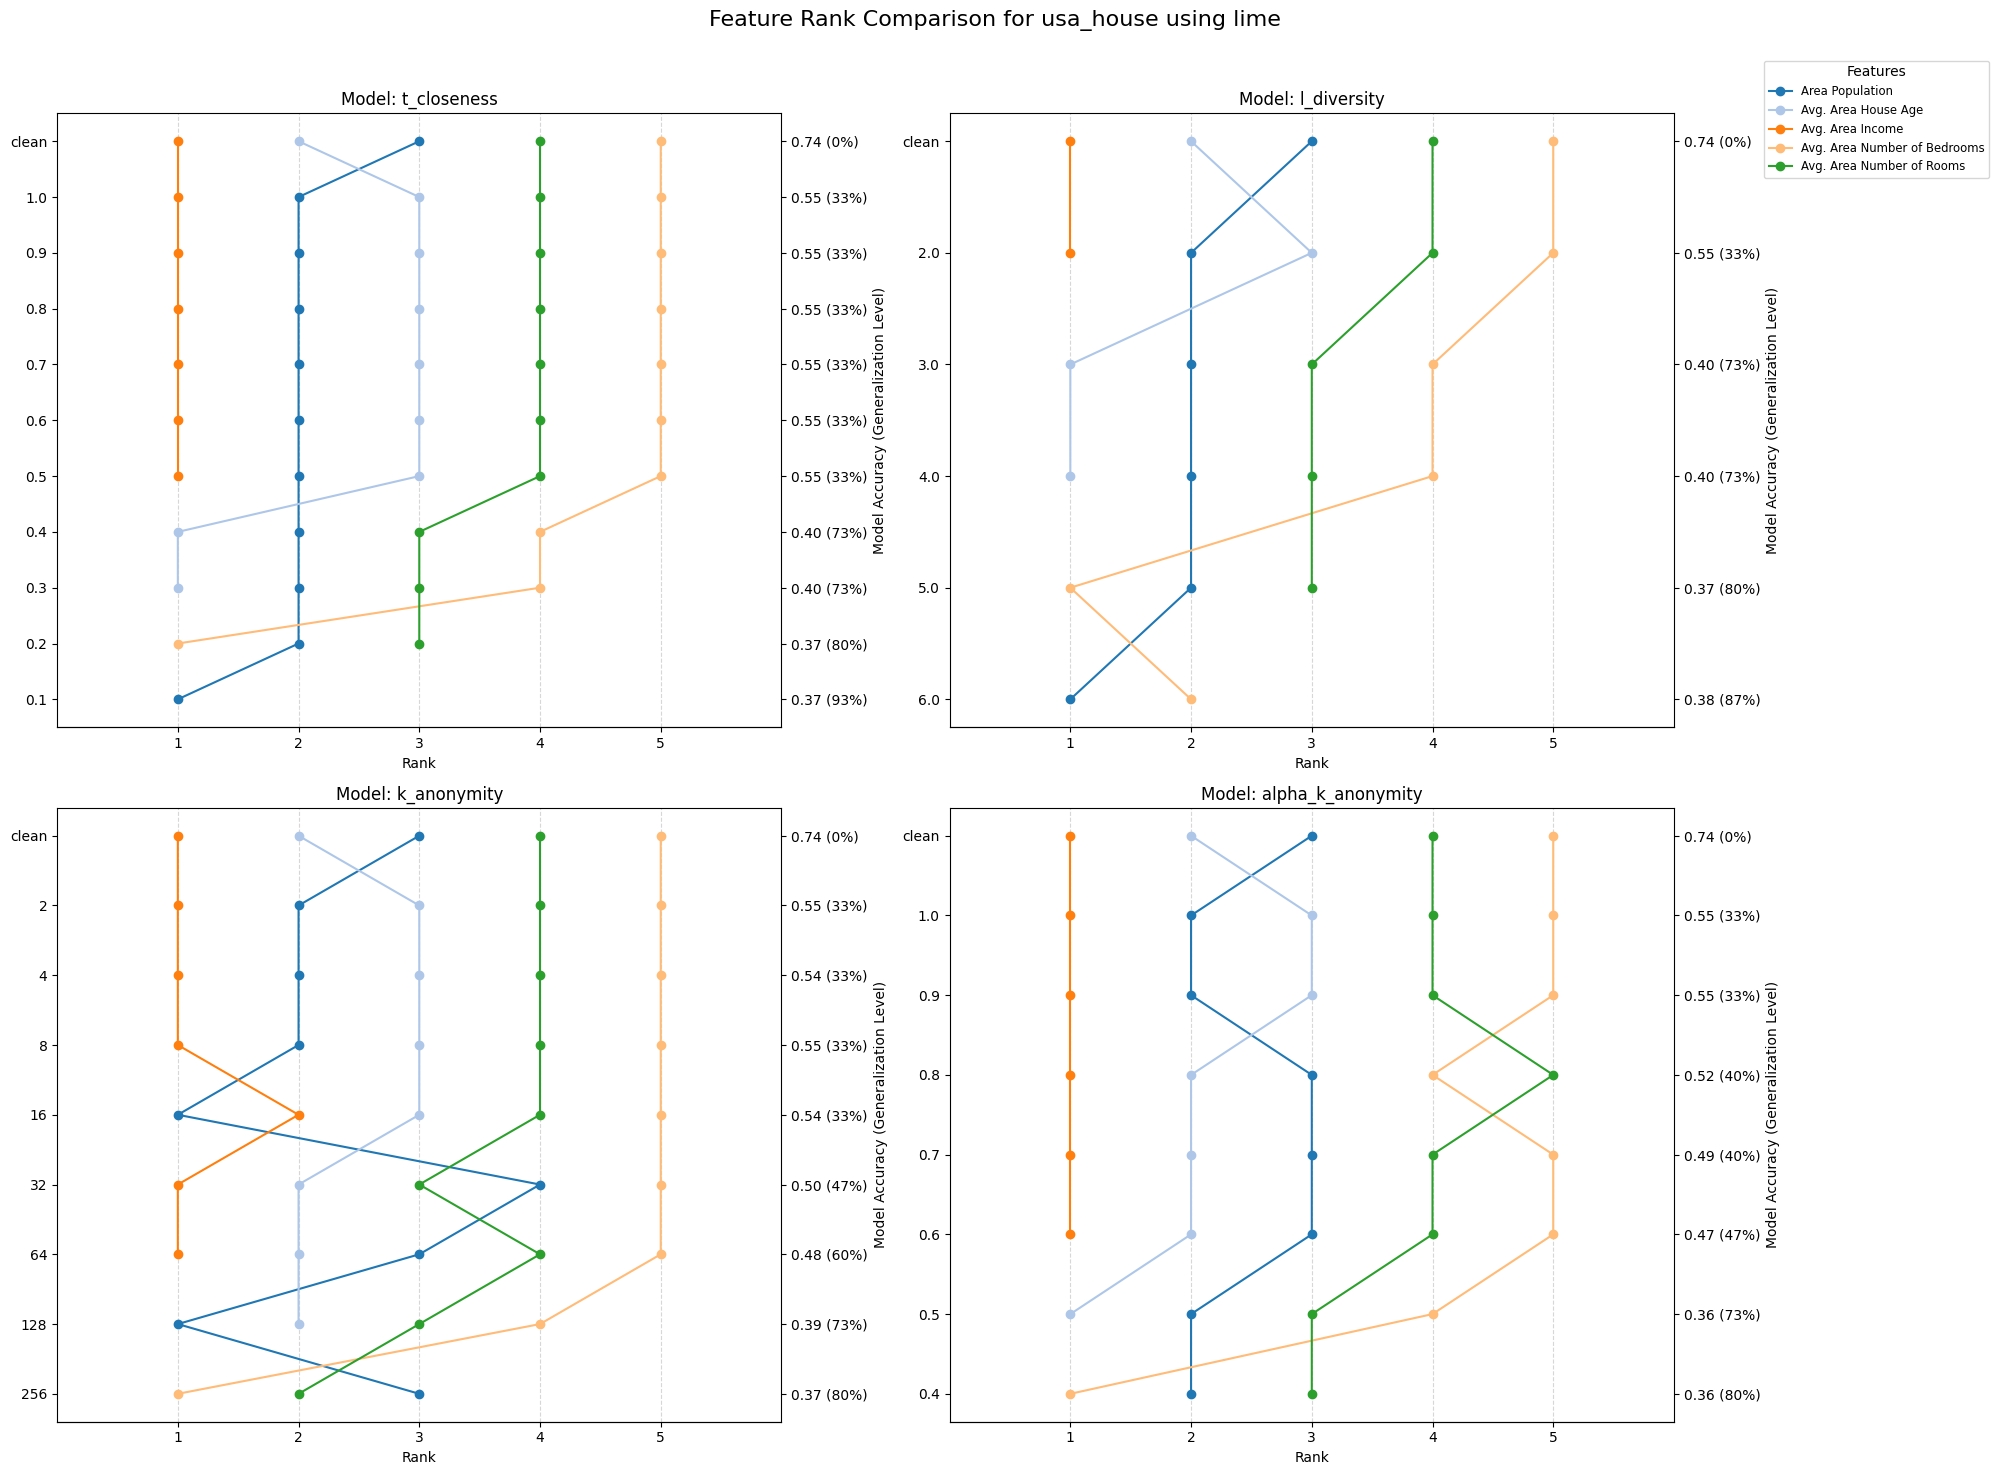

In [10]:
usa_house.plot_line("lime")

The importance of features are all over the place. The features that disappear first are the features with the most diversity. Here, all the features have taxonomy trees of same structure, so they simply get generalized in the "rolling" order they appear in the dataframe. 
Sadly, it is the most important feature that is generalized first, since it is the one that disappears the fastest.   
While t-closeness looks very stable (although the ranking is changed) and k_anonimity looks stable as well, they just look stable because the initial dataset satisfy the values for k and t multiple times. In fact, every time it is generalized the rankings of the feature changes. 

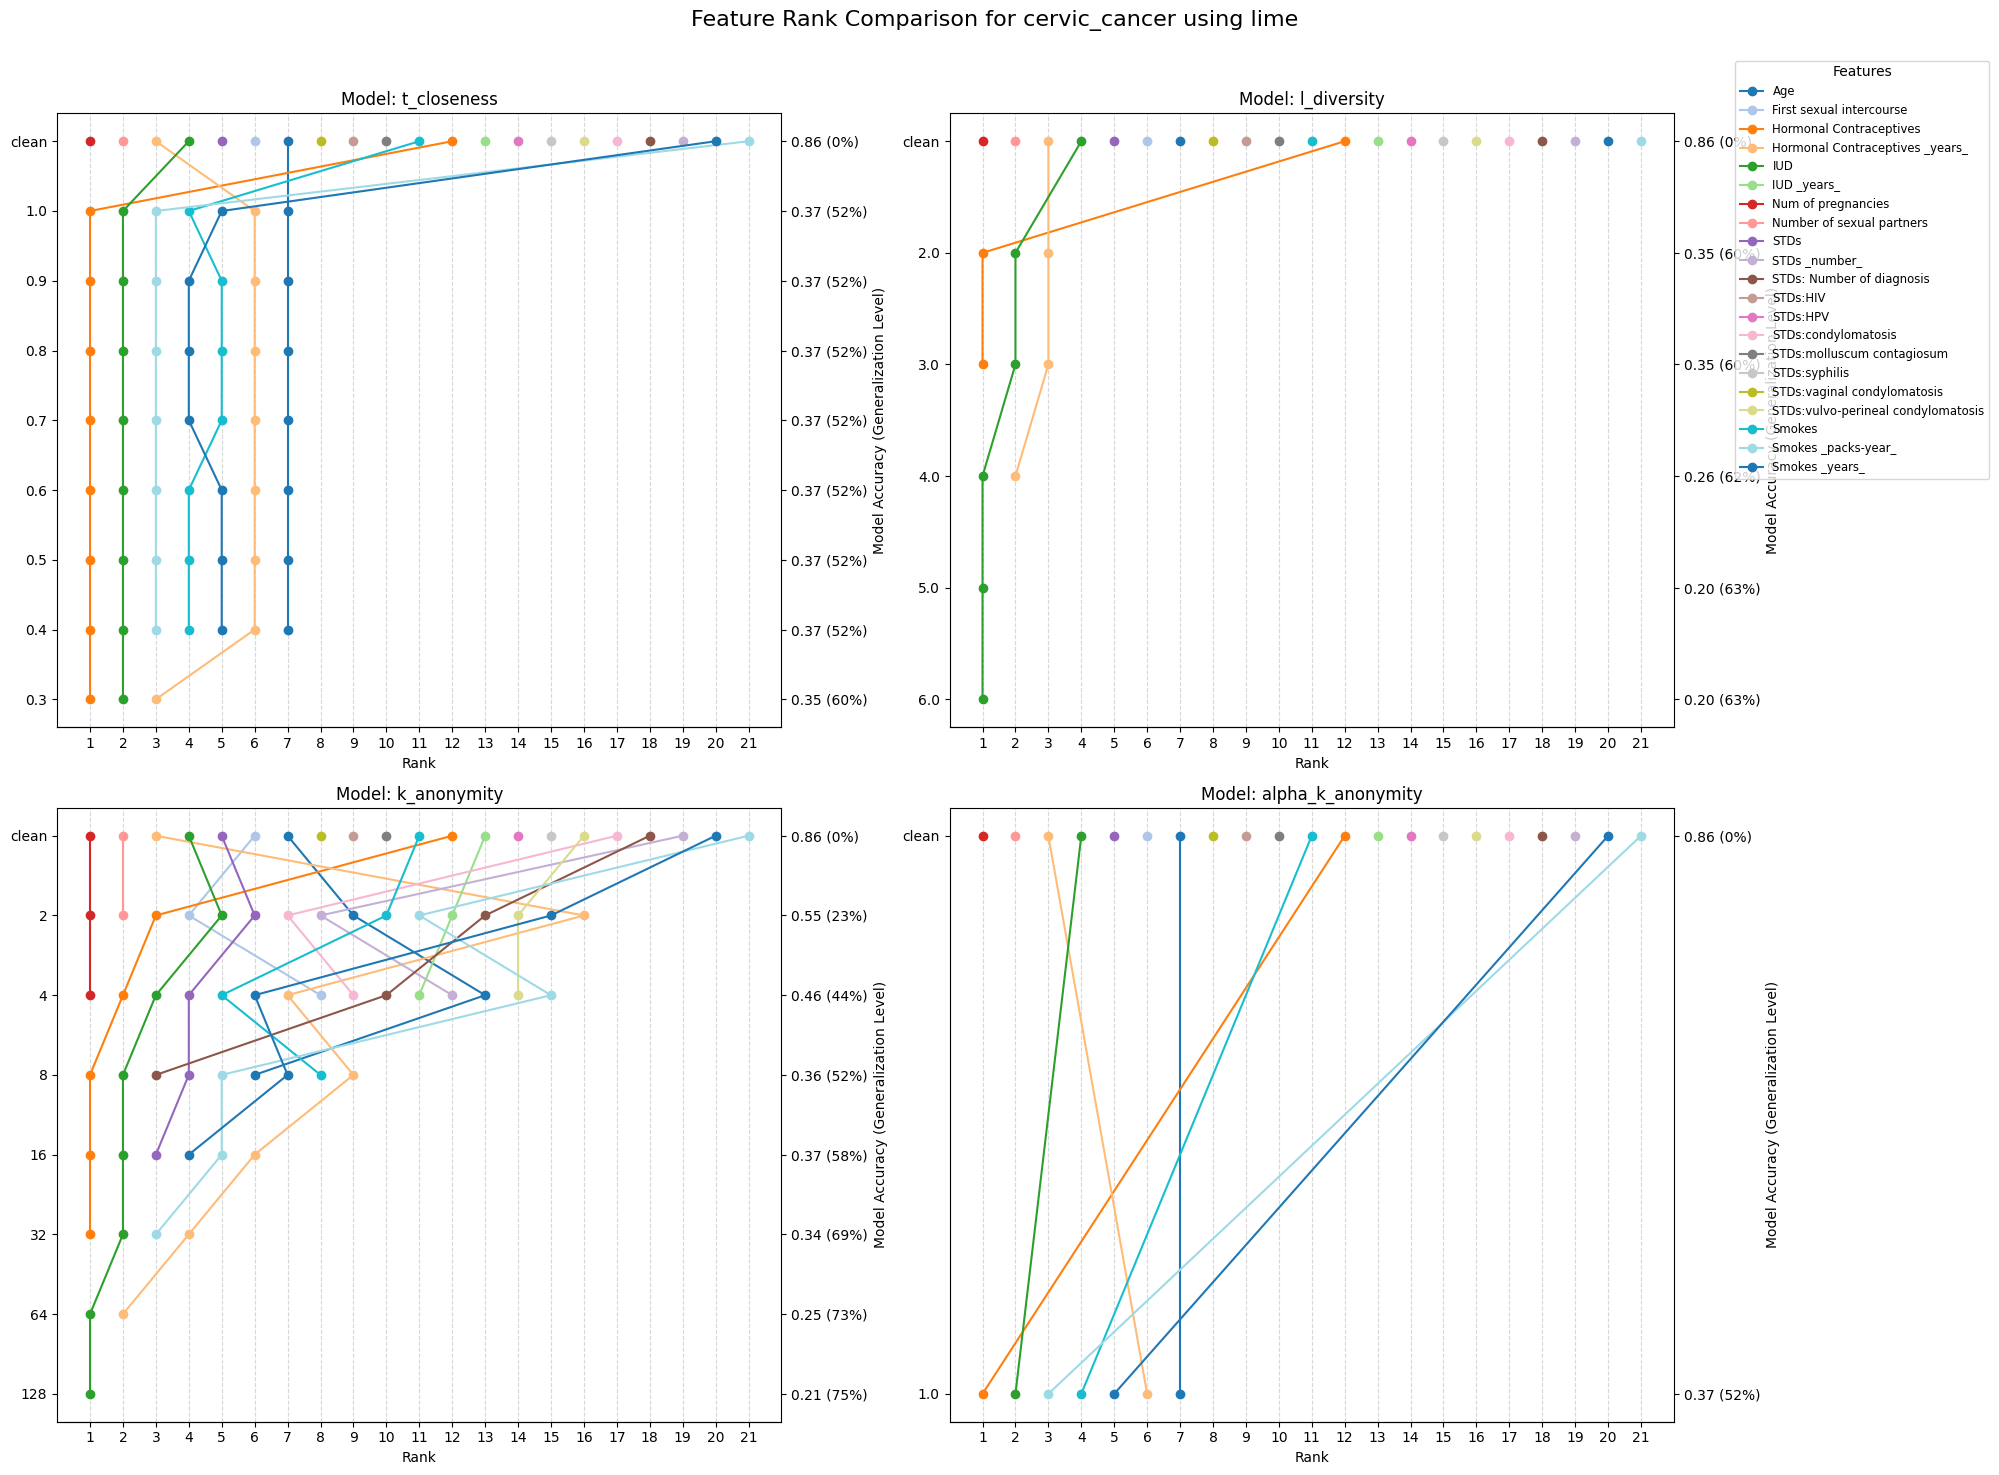

In [11]:
cervic_cancer.plot_line("lime")

It looks quite bad. Again, t closeness looks stable only because the first dataset that satisfy $t=1.0$ also satisfies $t=0.4$, and we are basically seeing the same dataset throughout the entire graph.  
l-diversity becomes very generalized very quicklly. It is rather hard to wrap your head around this dataset because it has so many features. The fact that it must be generalized so much just to achieve $l=2$ while you can have much more features for $k=8$ indicates that some equivalence classes all belong to the same target class. In this dataset, the majority of people have no diagnosis (88% of the 800 or so instances) it has been undersamled and the other tagert classes (many with only 12 instances) have been over-sampled. Since around 230 instances have been created from the original 12 instances, all these 230 instances are quite similar. In a not so generalized dataset an equivalence class will therefore not contain that many mixed values. The 230 real instances part of the common target class most likely covers other areas of the high dimensional feature space, whereas the 12 instances can only span so much of high dimensional state space.  
Also, the fact alpha-k-anonymity can only be achived for $\alpha=1$ indicates that the equivalence classes for $l>1$ must be very large, since they canntot even satisfy $\alpha=0.9$  
**IDEA** maybe go back and remove some of the target features? The least common one. Also consider removing less important features. Or maybe use PCA  

# SHAP

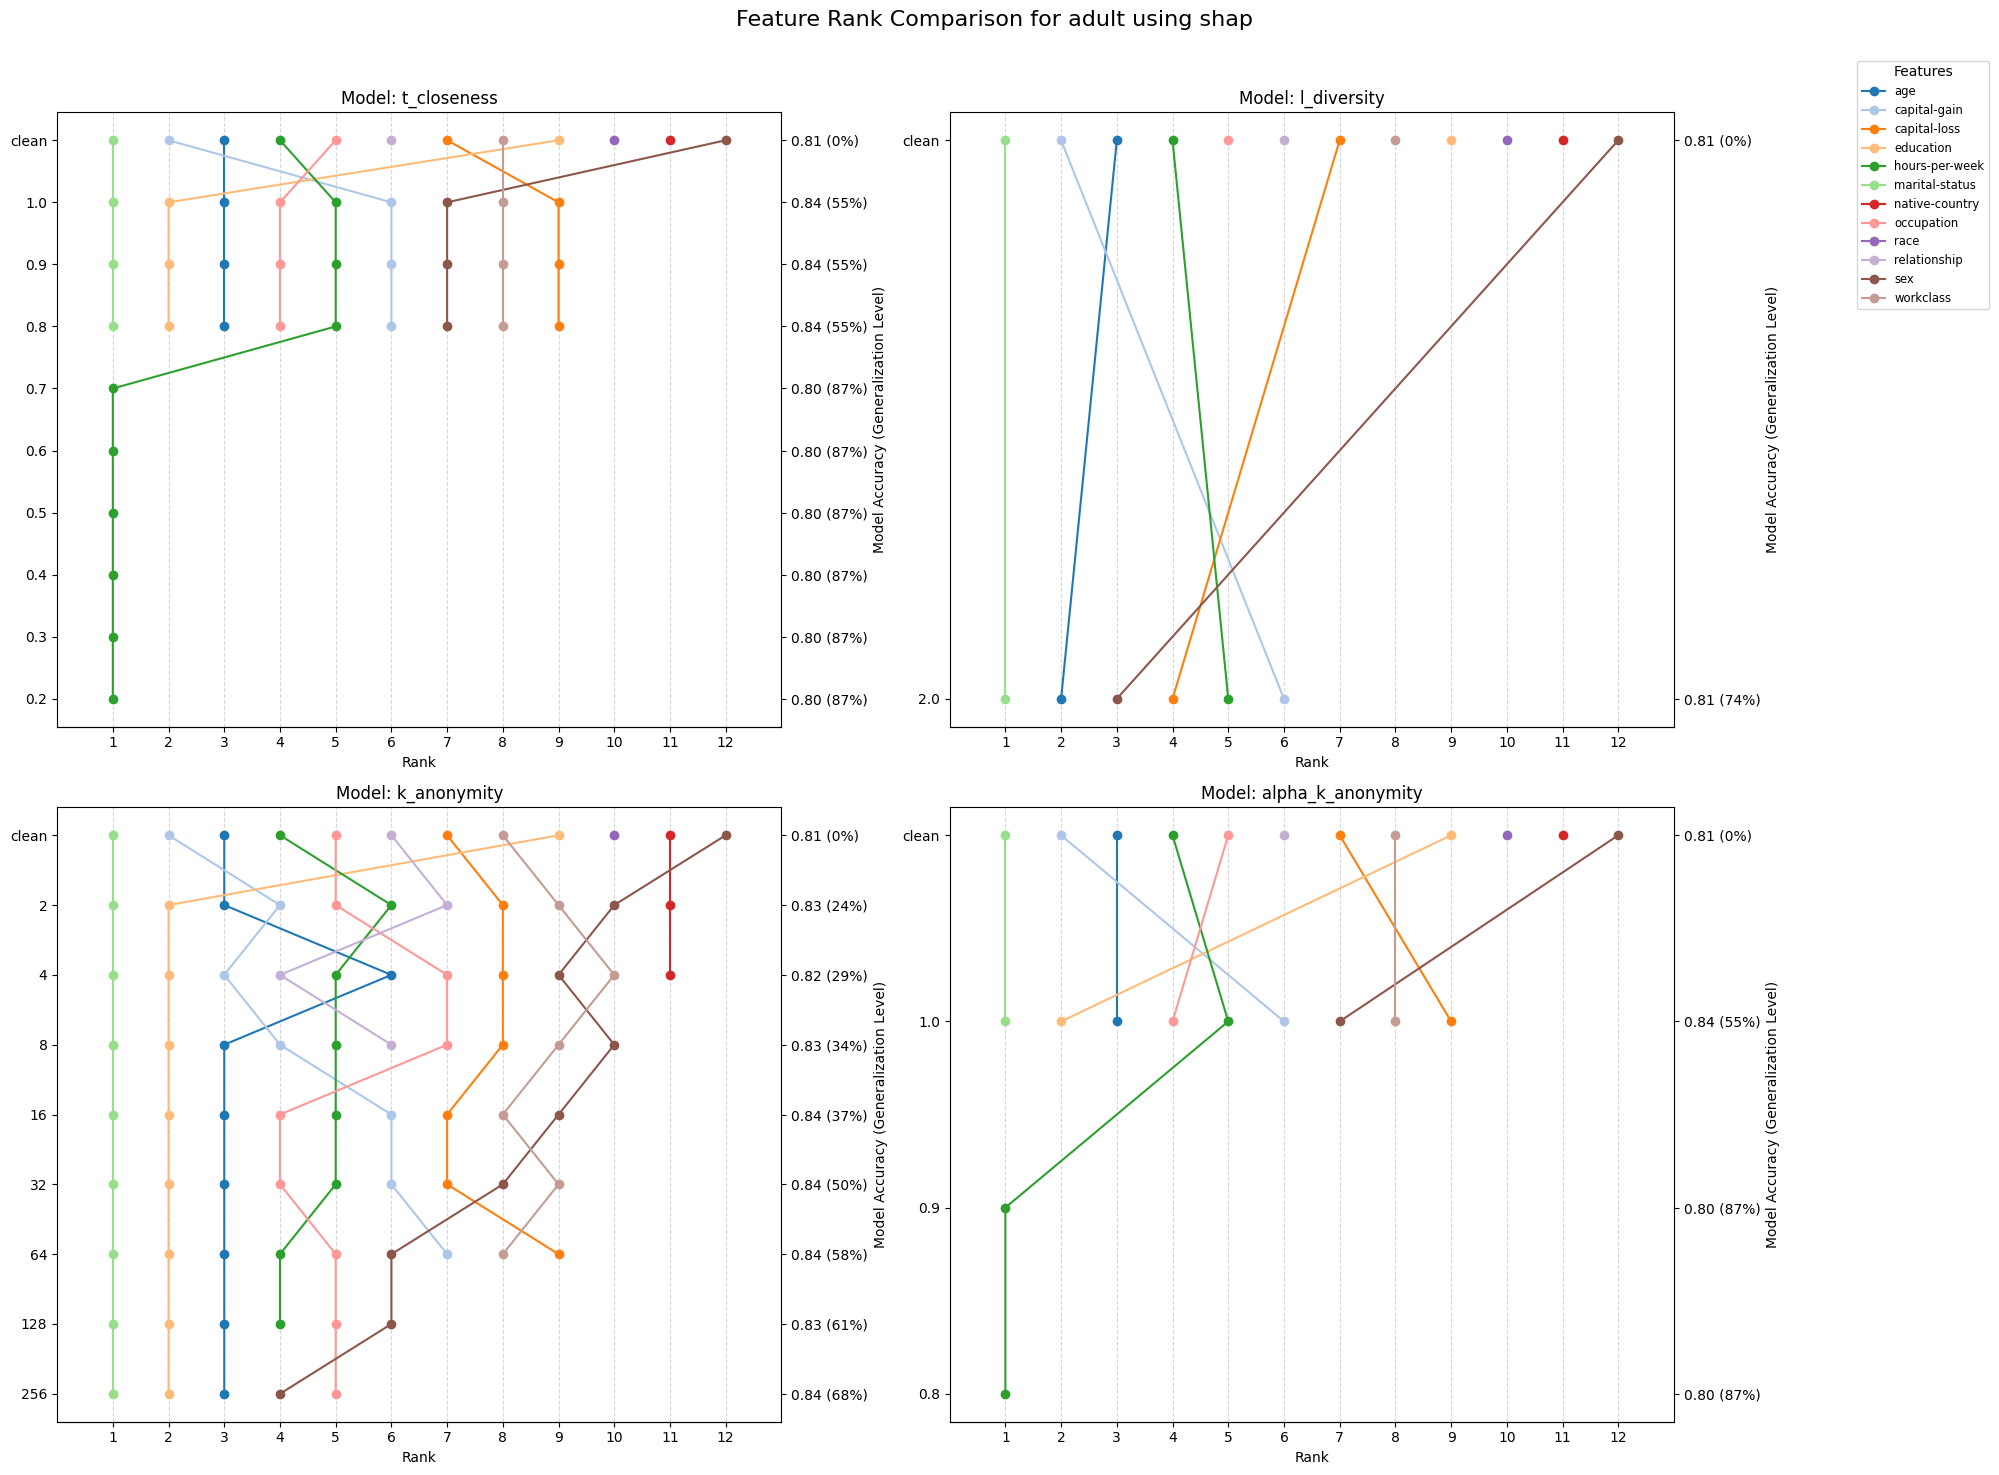

In [12]:
adult.plot_line("shap")

We again see that k anonymity does not have many effects. It is easy to construct equivalence classes.  


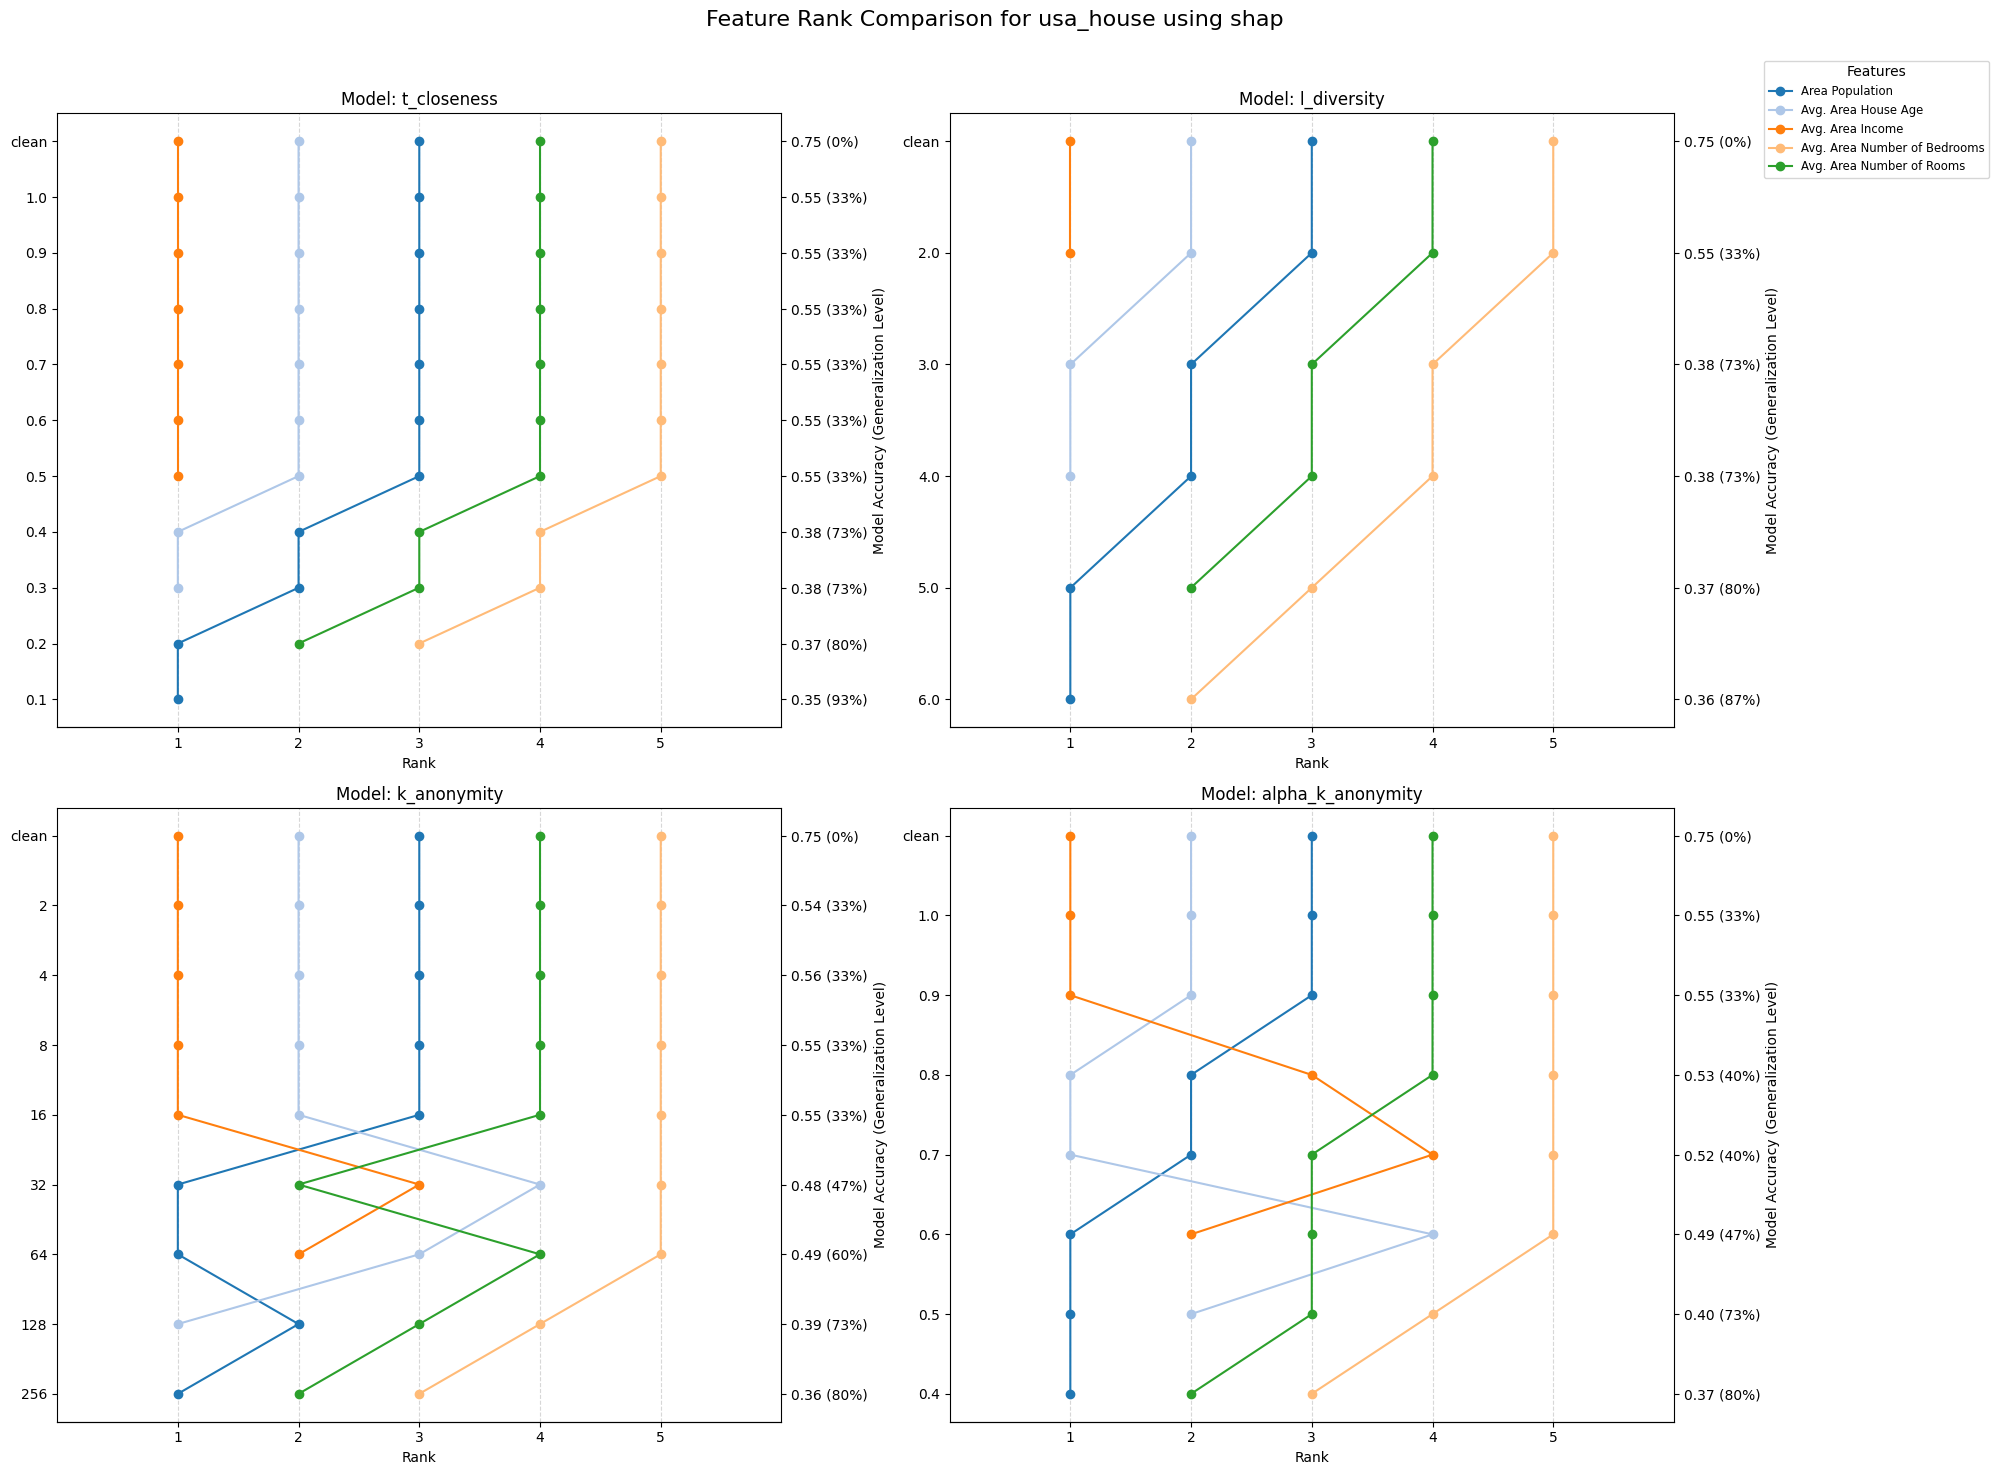

In [13]:
usa_house.plot_line("shap")

SHAP is more stable than lime  
Note, the datasets at k anonimity 8 and 16 are actually not the same, the accuracy just does not change significantly. The importance of the features change when using SHAP. When using lime, that is not the case however.  
Multiple times when a generalization occours, the ranking stay the same. That means that SHAP produces more stable feature rankings across generalized datasets. 

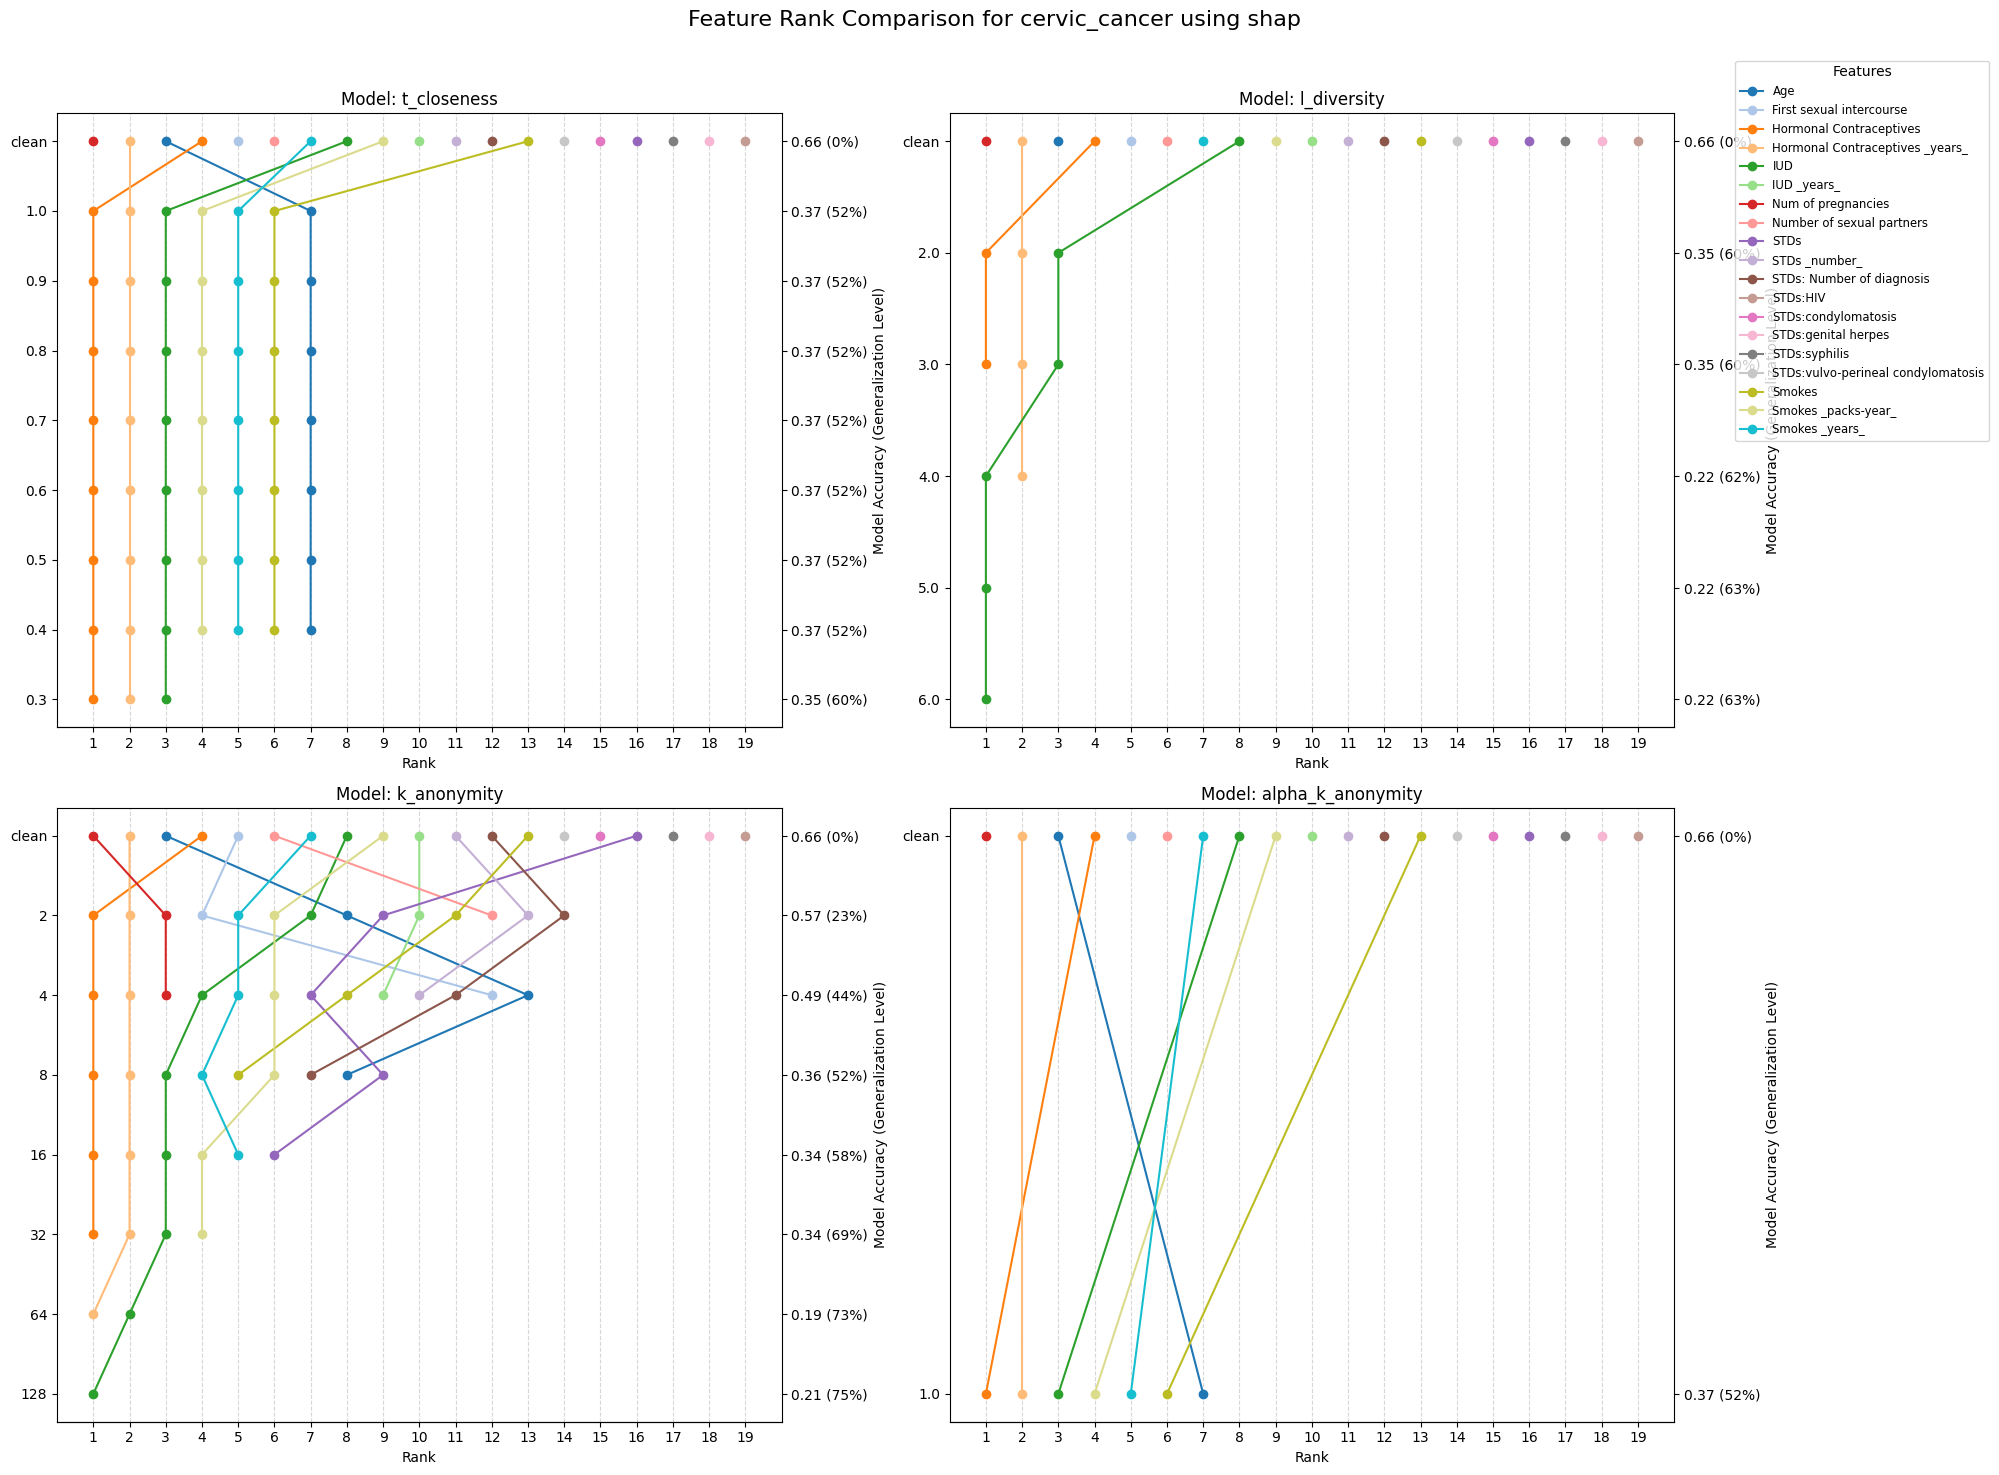

In [14]:
cervic_cancer.plot_line("shap")

Same story. SHAP looks quite a bit more stable. 

# Comparing Rankings  
In the below we compare how much the rankings given to features for different annonymized models correlate with the ranking produced by the clean data. On the y-axis we have different datasets, on the x-axis we have the level of anonymization that has been applied to a given dataset. The colors indicate the p-value of kendall Taus statistic where the alternative hypothesis is: the correlation is positive, i.e. there is a significant agreement in the rankings. Lower p-values indicate that the alternative is true, while higher p-values fail to reject that the null-hypothesis is false, i.e. the correlation is not positive. The null-hypothesis means that either the rankigns are rather random compared to one another or they might straight up be in disagreement

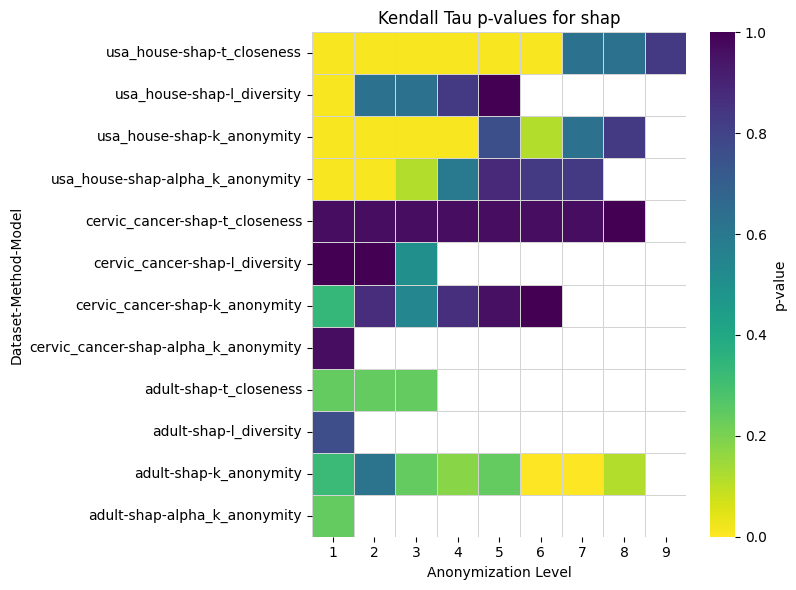

In [15]:
pl = plot_creator_2.PlotCreator(["usa_house", "cervic_cancer", "adult"])
pl.plot_heatmap(methods=["shap"])

Whether or not the null-hypothesis can be rejected, i.e. the rankings do not have a positive correlation, strongly depends on the dataset. The cervic cancer dataset produces rankings that do not correlate with the clean ranking at all. Note, how in k anonymity the p value goes up and down. This indicates that the way the hiearachies have been applied to the dataset has a huge impact on the ranking of the features!  
The usa house has less features and it is therefore easier for it to be in agreement (and disagreement). Also here we see that the p-value does not increase monotonically. It goes up and down, indicating that it applying a hiearchy in to a specifc level makes the rankings more agrreable. Both k anonymity and t closeness does not change the datasets a lot for different values, and the ranking is valid for that one. Therefore we have the two long yellow tails.  
For the adult dataset, all datasets generally produce more statistically evidence to reject the null-hypothesis, showing that that the rankings are in general more agreeable. Again, here the dataset contains a lot of instances and we humans are rather identical, meaning not a lot of granualarity is lost for every applied hierarchy. Note again, k anonymity shows fluctuating values for p. 

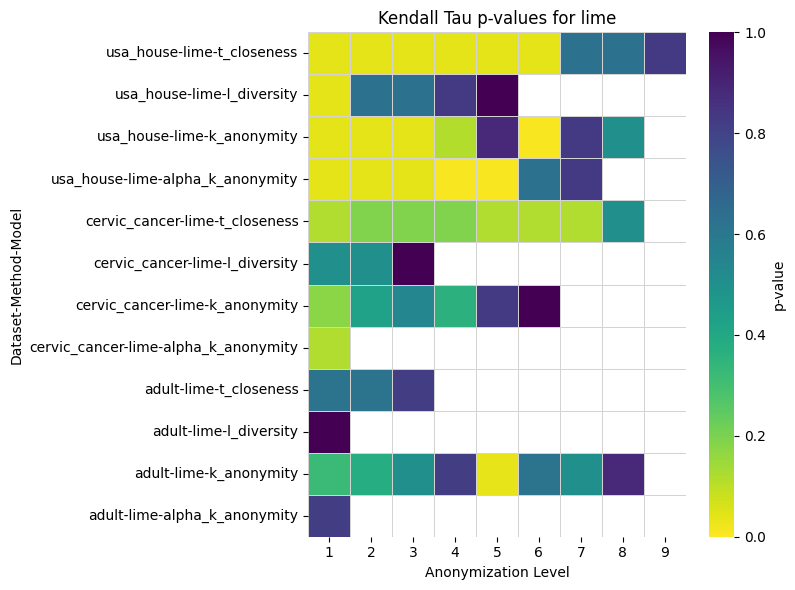

In [16]:
pl.plot_heatmap(methods=["lime"])

Looking at the heat map, lime produces rankings for which there is more statistical evidence for a positive correlation for some datasets and less for other datasets. They look quite similar for the usa house dataset, whereas it produces rankings for the cervic cancer dataset for which there is more statistical evidence to reject the null-hypothesis. However, it is the opposite for the adult dataset. 

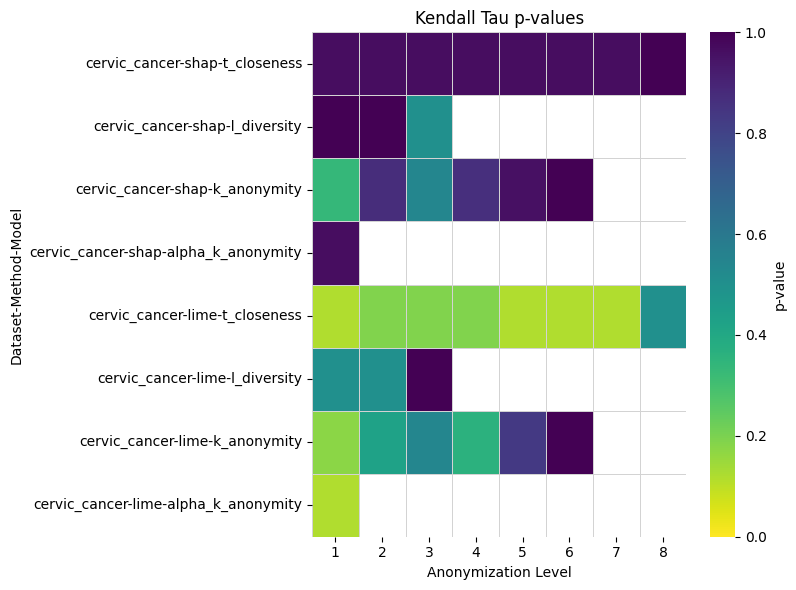

In [17]:
pl.plot_heatmap(datasets=["cervic_cancer"])

For the cervic cancer dataset, we clearly see that there is more statistically evidence to reject the null-hypothesis for the produced rankings compared to shap. I have read somewhere that shap performs bad for many features (here we have 20 ish). This shows that lime might perform better than shap. 

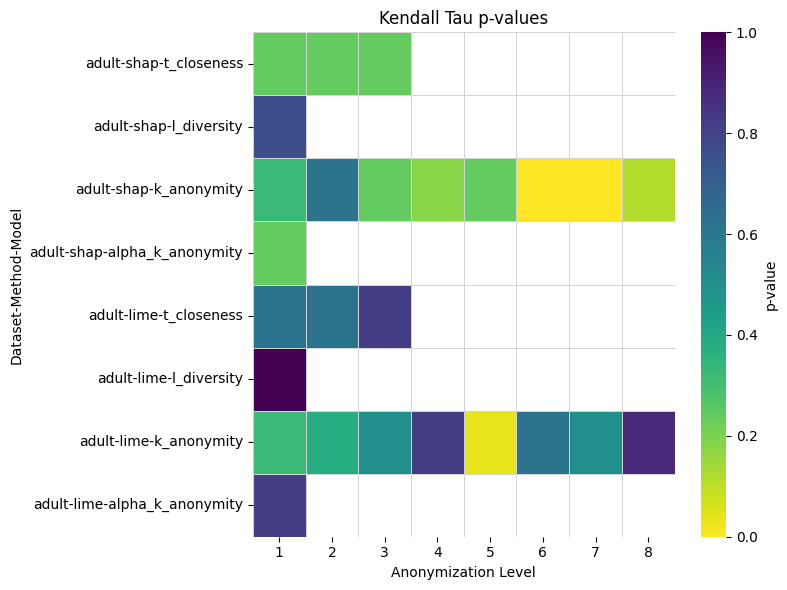

In [18]:
pl.plot_heatmap(datasets=["adult"])

The adult dataset has fewer features. Here we see that shap does a better job than lime at producing rankings that are agrees with the ranking of the clean dataset. 